# Data Practitioner Salary Analysis

This notebook sets up an API-first workflow in Python to answer:

**How much do we get paid?**

The analysis is designed to compare salary variation by:

- **role descriptor**
- **state**

It uses the **BLS OEWS API** as the primary source for salary data and keeps the role-to-occupation mapping explicit so the methodology is transparent and reproducible.


## 1. Install and import packages

Run the install line once if needed.


In [1]:
# Uncomment if needed
# !pip install requests pandas matplotlib

import requests
import pandas as pd
import matplotlib.pyplot as plt
from itertools import islice


## 2. Define state codes and role mappings

Important: the role mapping below includes **placeholders for some roles**. You should review and finalize these before submitting your assignment.

The core idea is that **"Data Practitioner"** is a broad umbrella, while the BLS API requires **standard occupation codes (SOC)**.


In [2]:
STATE_FIPS = {
    "AL": "0100000", "AK": "0200000", "AZ": "0400000", "AR": "0500000",
    "CA": "0600000", "CO": "0800000", "CT": "0900000", "DE": "1000000",
    "DC": "1100000", "FL": "1200000", "GA": "1300000", "HI": "1500000",
    "ID": "1600000", "IL": "1700000", "IN": "1800000", "IA": "1900000",
    "KS": "2000000", "KY": "2100000", "LA": "2200000", "ME": "2300000",
    "MD": "2400000", "MA": "2500000", "MI": "2600000", "MN": "2700000",
    "MS": "2800000", "MO": "2900000", "MT": "3000000", "NE": "3100000",
    "NV": "3200000", "NH": "3300000", "NJ": "3400000", "NM": "3500000",
    "NY": "3600000", "NC": "3700000", "ND": "3800000", "OH": "3900000",
    "OK": "4000000", "OR": "4100000", "PA": "4200000", "RI": "4400000",
    "SC": "4500000", "SD": "4600000", "TN": "4700000", "TX": "4800000",
    "UT": "4900000", "VT": "5000000", "VA": "5100000", "WA": "5300000",
    "WV": "5400000", "WI": "5500000", "WY": "5600000",
}

# Review these SOC codes before final submission.
ROLE_TO_SOC = {
    "Data Scientist": "15-2051",
    "Data Analyst": "15-2051",   # placeholder proxy
    "Data Architect": "15-1243", # placeholder proxy
    "Business Analyst": "13-1111",  # placeholder proxy
    "Data Engineer": "15-1252",     # placeholder proxy
}

role_definitions = pd.DataFrame([
    {
        "role_descriptor": role,
        "soc_code": soc,
        "status": "direct" if role == "Data Scientist" else "proxy - review",
    }
    for role, soc in ROLE_TO_SOC.items()
])

role_definitions


,role_descriptor,soc_code,status
0,Data Scientist,15-2051,direct
1,Data Analyst,15-2051,proxy - review
2,Data Architect,15-1243,proxy - review
3,Business Analyst,13-1111,proxy - review
4,Data Engineer,15-1252,proxy - review


## 3. BLS OEWS series builder

The OEWS API uses a structured series ID. For this project, we will pull:

- **state-level** data
- **all industries**
- **occupation-specific** wages
- **annual mean wage** by default

Measure codes:

- `04` = annual mean wage
- `13` = annual median wage


In [3]:
API_URL = "https://api.bls.gov/publicAPI/v2/timeseries/data/"
MEASURE_CODE = "04"  # change to "13" for annual median wage

def build_oews_series_id(state_area_code: str, soc_code: str, measure_code: str = "04") -> str:
    soc = soc_code.replace("-", "")
    # OE + U + S + area(7) + industry(000000) + occupation(6) + data_type(2)
    return f"OEUS{state_area_code}000000{soc}{measure_code}"

def chunked(iterable, size):
    iterable = iter(iterable)
    while True:
        batch = list(islice(iterable, size))
        if not batch:
            break
        yield batch


## 4. Build the request list

This creates one BLS series per `(role, state)` pair.


In [4]:
series_ids = []
series_meta = {}

for role, soc in ROLE_TO_SOC.items():
    for state_abbr, state_area_code in STATE_FIPS.items():
        sid = build_oews_series_id(state_area_code, soc, MEASURE_CODE)
        series_ids.append(sid)
        series_meta[sid] = {
            "role": role,
            "soc_code": soc,
            "state": state_abbr,
        }

len(series_ids)


255

## 5. Pull data from the BLS API

The public BLS API accepts up to 50 series IDs per request, so we batch the calls.


In [5]:
all_rows = []

for batch in chunked(series_ids, 50):
    payload = {"seriesid": batch}
    response = requests.post(API_URL, json=payload, timeout=30)
    response.raise_for_status()
    result = response.json()

    for series in result["Results"]["series"]:
        sid = series["seriesID"]
        points = series.get("data", [])
        if not points:
            continue

        latest = points[0]  # BLS returns latest period first
        meta = series_meta[sid]

        all_rows.append({
            "role": meta["role"],
            "soc_code": meta["soc_code"],
            "state": meta["state"],
            "year": latest.get("year"),
            "period": latest.get("period"),
            "salary": pd.to_numeric(latest.get("value"), errors="coerce"),
            "series_id": sid,
        })

df = pd.DataFrame(all_rows)
df.head()


,role,soc_code,state,year,period,salary,series_id
0,Data Analyst,15-2051,AL,2024,A01,102970.0,OEUS010000000000015205104
1,Data Analyst,15-2051,AK,2024,A01,88690.0,OEUS020000000000015205104
2,Data Analyst,15-2051,AZ,2024,A01,112460.0,OEUS040000000000015205104
3,Data Analyst,15-2051,AR,2024,A01,104560.0,OEUS050000000000015205104
4,Data Analyst,15-2051,CA,2024,A01,155450.0,OEUS060000000000015205104


## 6. Basic validation

Check how many rows were retrieved and which year is represented in the current pull.


In [6]:
print("Rows:", len(df))
print("Distinct roles:", df['role'].nunique())
print("Distinct states:", df['state'].nunique())
print("Years returned:", sorted(df['year'].dropna().unique()))

df.sample(min(10, len(df)))


Rows: 130
Distinct roles: 4
Distinct states: 30
Years returned: ['2024']


,role,soc_code,state,year,period,salary,series_id
97,Business Analyst,13-1111,ME,2024,A01,92730.0,OEUS230000000000013111104
36,Data Analyst,15-2051,GA,2024,A01,111020.0,OEUS130000000000015205104
70,Data Architect,15-1243,LA,2024,A01,NaN,OEUS220000000000015124304
72,Data Architect,15-1243,MD,2024,A01,143020.0,OEUS240000000000015124304
106,Data Engineer,15-1252,AZ,2024,A01,133140.0,OEUS040000000000015125204
31,Data Analyst,15-2051,CO,2024,A01,118250.0,OEUS080000000000015205104
84,Business Analyst,13-1111,CT,2024,A01,120670.0,OEUS090000000000013111104
22,Data Analyst,15-2051,MI,2024,A01,102030.0,OEUS260000000000015205104
67,Data Architect,15-1243,IA,2024,A01,124910.0,OEUS190000000000015124304
82,Business Analyst,13-1111,CA,2024,A01,120410.0,OEUS060000000000013111104


## 7. Summaries for analysis

Create tables that support the final story.


In [10]:
salary_by_role = (
    df.groupby('role', as_index=False)['salary']
      .mean()
      .sort_values('salary', ascending=False)
)

salary_by_state = (
    df.groupby('state', as_index=False)['salary']
      .mean()
      .sort_values('salary', ascending=False)
)

salary_matrix = df.pivot_table(index='state', columns='role', values='salary', aggfunc='mean')

salary_by_role.head(), salary_by_state.head()

(               role         salary
 2    Data Architect  133323.600000
 3     Data Engineer  129538.461538
 1      Data Analyst  111482.600000
 0  Business Analyst  109159.600000,
    state    salary
 4     CA  155976.0
 26    WA  149920.0
 19    MA  146917.5
 7     DC  145248.0
 25    VA  142230.0)

## 8. Visualization 1: Average salary by role

This chart shows which role descriptors are paid more on average across all states in the dataset.


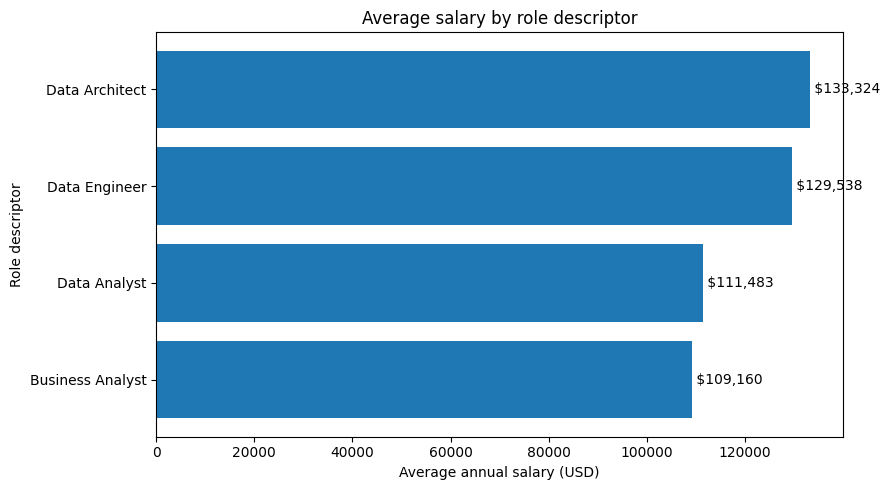

In [8]:
plot_role = salary_by_role.sort_values('salary')

plt.figure(figsize=(9, 5))
plt.barh(plot_role['role'], plot_role['salary'])
plt.xlabel('Average annual salary (USD)')
plt.ylabel('Role descriptor')
plt.title('Average salary by role descriptor')

for i, v in enumerate(plot_role['salary']):
    plt.text(v, i, f' ${v:,.0f}', va='center')

plt.tight_layout()
plt.show()


## 9. Visualization 2: Salary heatmap by state and role

This is usually the most effective view for the assignment because it highlights **variation by both state and role** in one figure.


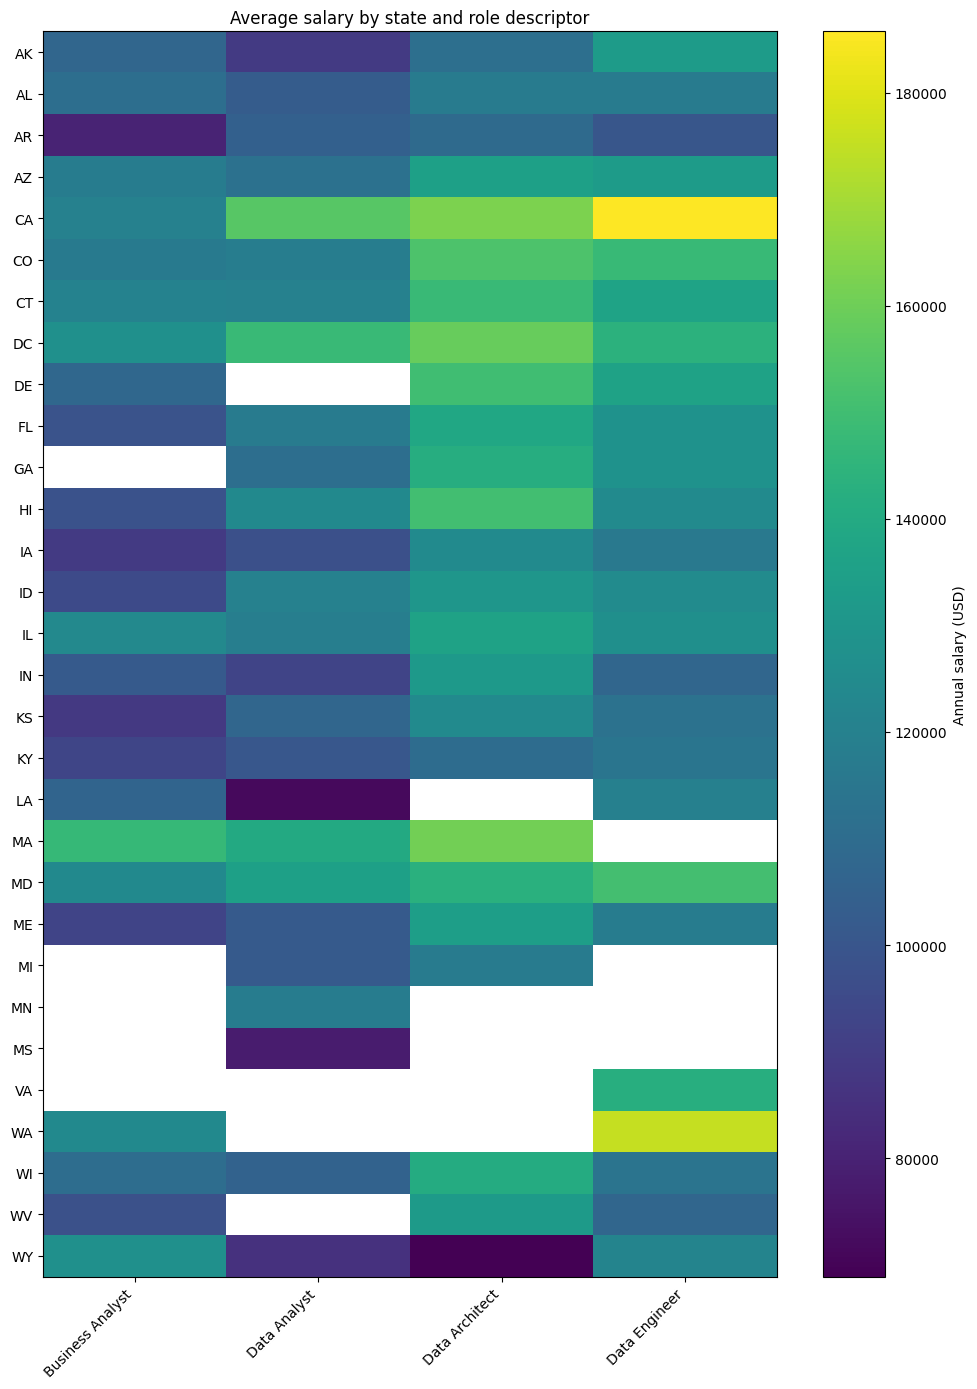

In [11]:
heatmap_data = salary_matrix.sort_index()

plt.figure(figsize=(10, 14))
plt.imshow(heatmap_data, aspect='auto')
plt.colorbar(label='Annual salary (USD)')
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right')
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title('Average salary by state and role descriptor')
plt.tight_layout()
plt.show()


## 10. Optional: Top and bottom states for each role

This helps identify the most salient findings for annotations in your final story.


In [12]:
top_bottom_rows = []

for role, group in df.groupby('role'):
    g = group.sort_values('salary')
    if len(g) == 0:
        continue

    top_bottom_rows.append({
        'role': role,
        'lowest_state': g.iloc[0]['state'],
        'lowest_salary': g.iloc[0]['salary'],
        'highest_state': g.iloc[-1]['state'],
        'highest_salary': g.iloc[-1]['salary'],
    })

top_bottom = pd.DataFrame(top_bottom_rows)
top_bottom


,role,lowest_state,lowest_salary,highest_state,highest_salary
0,Business Analyst,AR,80610.0,GA,NaN
1,Data Analyst,LA,71740.0,DE,NaN
2,Data Architect,WY,68880.0,LA,NaN
3,Data Engineer,AR,100380.0,CA,185750.0


## 11. Save outputs

Use this if you want to export the cleaned dataset for Tableau, Power BI, Excel, or slides.


In [ ]:
# df.to_csv('data_practitioner_salary_by_role_state.csv', index=False)
# salary_matrix.to_csv('data_practitioner_salary_matrix.csv')


## 12. Notes for the writeup

You can adapt this language for your methodology section:

- Salary data was pulled from the **Bureau of Labor Statistics OEWS API**.
- Because **Data Practitioner** is not a formal BLS occupation, role descriptors were mapped to SOC occupation codes.
- Some roles required **proxy mappings**, which should be documented clearly.
- The most useful visualization for the story is the **state × role heatmap**, supported by a ranked summary chart by role.

Before final submission, you should:

1. confirm each SOC mapping,
2. decide whether to use **mean** or **median** salary,
3. add annotations for the most important findings,
4. polish titles, subtitles, and labels for clarity.
